In [1]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

2025-04-03 11:40:38.463495: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743673238.526648   11747 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743673238.547211   11747 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 11:40:38.608439: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
NUM_SAMPLES = 300

config_base = load_config('configs/default.yaml')

fixed_points = {
        (0.0, 0.0) : "unstable", 
    } 
config = config_base
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.0
config["freq_save"] = 0


version : default
seed : 1
alpha : -1.0
beta : 1.0
delta : 1.0
x0 : 0.2
x_t0 : 0.2
T : 12
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularizer : no_reg
reg_coeff : 0.0
reg_decay : linear
reg_epochs : 0.5


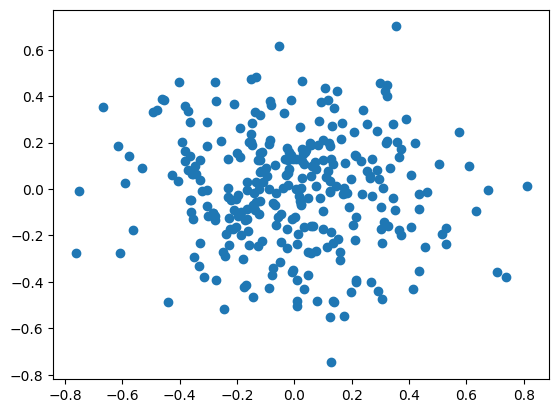

/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2025-04-03 11:40:48.910208: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***
Training started...
    0/25000 | loss_P: 6.08e-01 | loss_IC: 4.56e-01
 1000/25000 | loss_P: 7.36e-05 | loss_IC: 1.57e-07
 2000/25000 | loss_P: 6.24e-05 | loss_IC: 1.07e-07
 3000/25000 | loss_P: 2.16e-05 | loss_IC: 5.94e-08
 4000/25000 | loss_P: 1.75e-05 | loss_IC: 9.68e-09
 5000/25000 | loss_P: 2.52e-05 | loss_IC: 3.36e-07
 6000/25000 | loss_P: 1.84e-05 | loss_IC: 2.04e-07
 7000/25000 | loss_P: 9.00e-06 | loss_IC: 3.72e-07
 8000/25000 | loss_P: 7.02e-06 | loss_IC: 2.23e-07
 9000/25000 | loss_P: 4.67e-06 | loss_IC: 7.03e-09
10000/25000 | loss_P: 1.15e-06 | loss_IC: 3.77e-08
11000/25000 | loss_P: 1.35e-06 | loss_IC: 6.92e-08
12000/25000 | loss_P: 3.38e-07 | loss_IC: 6.18e-09
13000/25000 | loss_P: 4.15e-07 | loss_IC: 4.74e-09
14000/25000 | loss_P: 8.48e-06 | loss_IC: 1.54e-06
15000/25000 | loss_P: 1.75e-05 | loss_IC: 2.52e-06
16000/25000 | loss_P: 1.68e-05 | loss_IC: 1.88e-07
17000/25000 | loss_P: 8.29e-06 | loss_IC: 9.59e-07
18000/25000 | loss_P: 2.93e-0

In [ ]:
x0s = np.random.normal(0, 0.25, size=NUM_SAMPLES)
x_t0s = np.random.normal(0, 0.25, size=NUM_SAMPLES)


plt.scatter(x0s, x_t0s)
plt.show()

for i in range(15, NUM_SAMPLES):
    config["x0"] = float(x0s[i])
    config["x_t0"] = float(x_t0s[i])
    
    try:
        # Without regularization
        config["regularizer"] = "no_reg"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        dirname = f"logs/models/visualization_experiments/no_reg"
        if not os.path.exists(dirname):
            os.makedirs(dirname)

        PINN.save_weights(f"{dirname}/run_{i}.pkl")

        # With regularization
        config["regularizer"] = "reg_derivative_unstable_fp"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        dirname = f"logs/models/visualization_experiments/reg"
        if not os.path.exists(dirname):
            os.makedirs(dirname)

        PINN.save_weights(f"{dirname}/run_{i}.pkl")

    except Exception as e:
        print(e)
            
     

In [ ]:
plt.rcParams.update({'font.size': 12,
                     'axes.titlepad': 10,
                     'axes.titlesize': 14,
                     'axes.labelsize': 12,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })